# Baseline Alpha Model

## Objective

Test whether raw technical features contain predictive information.

## Model

Random Forest Regressor

## Evaluation

- R²
- MAE
- Correlation
- Feature Importance

In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error
)

from scipy.stats import spearmanr

import matplotlib.pyplot as plt

In [2]:
feature_df = pd.read_csv(
    "feature_df_clean.csv",
    index_col=[0,1],
    parse_dates=[0]
)

print(feature_df.shape)

feature_df.head()

(845236, 11)


mom21     mom63    mom126     vol21     vol63  \
Date                                                                        
2015-07-07 3MINDIA.NS   -0.028814 -0.044600  0.264628  0.012119  0.025000   
           ABB.NS        0.105837  0.039956  0.075473  0.017977  0.017446   
           ACC.NS        0.049351 -0.091014  0.081320  0.013131  0.018228   
           AIAENG.NS     0.083120 -0.164473 -0.066578  0.015916  0.028475   
           APLAPOLLO.NS  0.023391 -0.116183  0.176847  0.025337  0.021545   

                         ema_distance  ema_slope      rsi14  future_return  \
Date                                                                         
2015-07-07 3MINDIA.NS       -0.000386   0.003061  51.521348       0.211150   
           ABB.NS            0.047123   0.010039  67.181723      -0.015551   
           ACC.NS            0.022314  -0.003859  72.808272      -0.071802   
           AIAENG.NS        -0.024456  -0.015916  63.326813      -0.036672   
           APLAPOLLO.NS     -0.018824  -0.017880  41.069316       0.120344   

                         market_mom21  market_vol21  
Date                                                 
2015-07-07 3MINDIA.NS        0.075832      0.008273  
           ABB.NS            0.075832      0.008273  
           ACC.NS            0.075832      0.008273  
           AIAENG.NS         0.075832      0.008273  
           APLAPOLLO.NS      0.075832      0.008273

In [3]:
features = [

    "mom21",
    "mom63",
    "mom126",

    "vol21",
    "vol63",

    "ema_distance",
    "ema_slope",

    "rsi14",

    "market_mom21",
    "market_vol21"
]

In [4]:
split_date = "2022-01-01"

train = feature_df.loc[
    feature_df.index.get_level_values(0)
    < split_date
]

test = feature_df.loc[
    feature_df.index.get_level_values(0)
    >= split_date
]

print(
    "Train Shape:",
    train.shape
)

print(
    "Test Shape:",
    test.shape
)

Train Shape: (524208, 11)
Test Shape: (321028, 11)


In [5]:
X_train = train[features]

y_train = train["future_return"]

X_test = test[features]

y_test = test["future_return"]

In [6]:
model = RandomForestRegressor(

    n_estimators=200,

    max_depth=8,

    min_samples_leaf=50,

    random_state=42,

    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [7]:
pred = model.predict(
    X_test
)

In [8]:
r2 = r2_score(
    y_test,
    pred
)

mae = mean_absolute_error(
    y_test,
    pred
)

corr = np.corrcoef(
    y_test,
    pred
)[0,1]

print(
    f"R²: {r2:.4f}"
)

print(
    f"MAE: {mae:.4f}"
)

print(
    f"Correlation: {corr:.4f}"
)

R²: -0.0965
MAE: 0.0825
Correlation: 0.0080


market_vol21    0.537268
market_mom21    0.225321
mom63           0.059658
mom126          0.057528
vol63           0.052471
rsi14           0.030819
vol21           0.015925
ema_slope       0.011024
ema_distance    0.005571
mom21           0.004415
dtype: float64


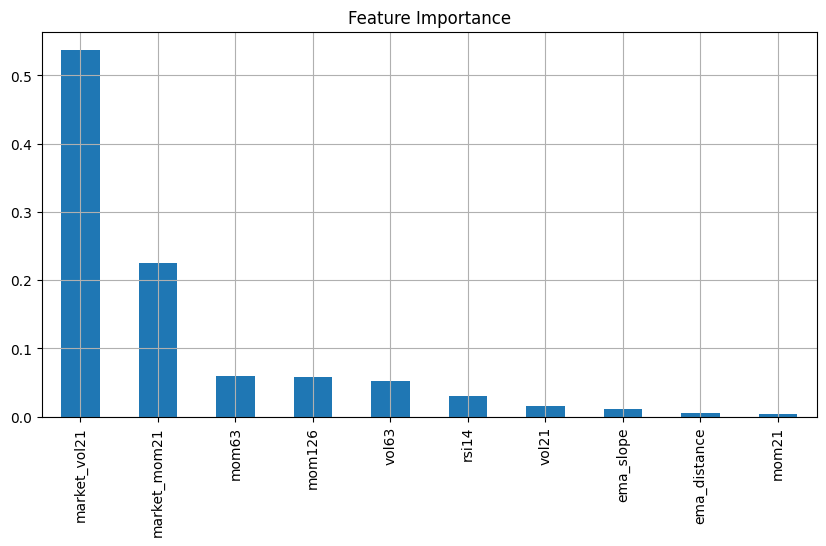

In [9]:
importance = pd.Series(

    model.feature_importances_,

    index=features

).sort_values(
    ascending=False
)

print(importance)

importance.plot(
    kind="bar",
    figsize=(10,5),
    title="Feature Importance"
)

plt.grid(True)

plt.show()

In [10]:
test = test.copy()

test["prediction"] = pred

daily_ic = []

for date, group in test.groupby(
    level=0
):

    if len(group) > 20:

        ic = spearmanr(

            group["prediction"],

            group["future_return"]

        )[0]

        daily_ic.append(ic)

mean_ic = np.nanmean(
    daily_ic
)

print(
    f"Mean Rank IC: {mean_ic:.4f}"
)

C:\Users\SaiAshwin\AppData\Local\Temp\ipykernel_14452\221369582.py:13: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  ic = spearmanr(


Mean Rank IC: 0.0043


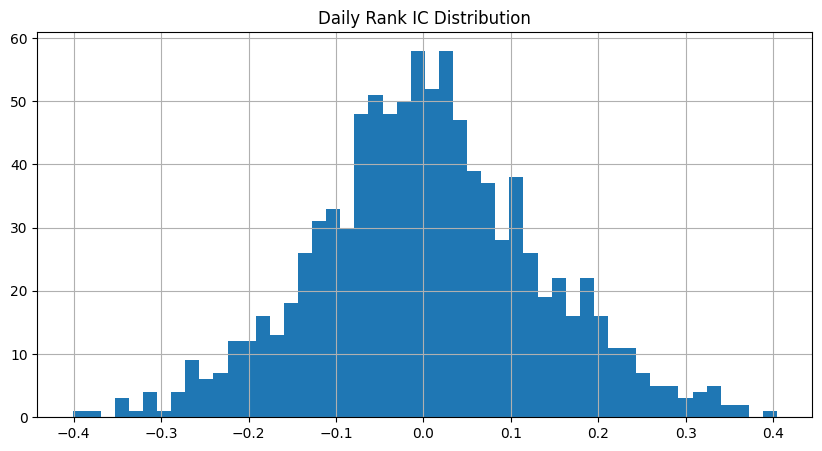

In [11]:
pd.Series(daily_ic).hist(
    bins=50,
    figsize=(10,5)
)

plt.title(
    "Daily Rank IC Distribution"
)

plt.grid(True)

plt.show()

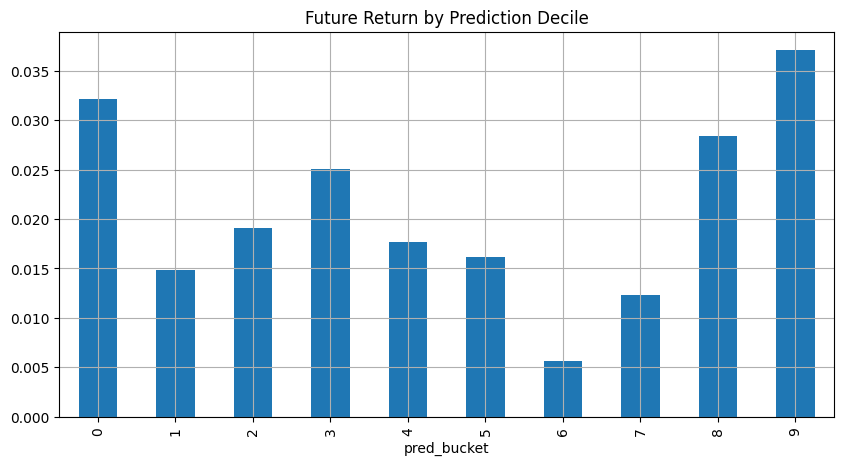

pred_bucket
0    0.032143
1    0.014817
2    0.019049
3    0.025085
4    0.017672
5    0.016107
6    0.005639
7    0.012295
8    0.028365
9    0.037083
Name: future_return, dtype: float64

In [12]:
test["pred_bucket"] = pd.qcut(
    test["prediction"],
    10,
    labels=False
)

bucket_returns = test.groupby(
    "pred_bucket"
)["future_return"].mean()

bucket_returns.plot(
    kind="bar",
    figsize=(10,5),
    title="Future Return by Prediction Decile"
)

plt.grid(True)

plt.show()

bucket_returns